In [1]:
# Churn model is a predictive model that tells whether a user is likely to stop using the services or not

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [3]:
df = pd.read_csv('netflix_customer_churn.csv')
df.sample(7)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
2275,35cdcfe1-c48a-43b6-8533-8f70aa35c713,38,Male,Standard,6.77,49,Europe,Mobile,13.99,1,Gift Card,3,0.14,Romance
4210,ad57c204-f497-4f4b-88fb-03a6ed249a42,70,Male,Premium,5.62,25,Europe,Desktop,17.99,0,Credit Card,3,0.22,Comedy
2168,eab99641-f7e9-4cba-a913-e1880044e640,22,Female,Standard,0.48,24,North America,Desktop,13.99,1,Gift Card,2,0.02,Romance
1416,1b03740b-7608-4b96-a78e-b48bebde5337,53,Male,Basic,3.37,54,South America,Desktop,8.99,1,PayPal,5,0.06,Comedy
4746,f34c660c-8130-46ea-b9eb-2b94983e70f0,52,Female,Premium,19.84,51,South America,Tablet,17.99,0,PayPal,4,0.38,Drama
2648,f500aa1d-d760-42ea-8cd1-725d5aa13413,69,Male,Standard,32.20,13,Asia,Mobile,13.99,0,Debit Card,1,2.30,Documentary
1929,f898a1fd-293e-40b3-9a40-e21de4828852,62,Female,Premium,25.53,51,Oceania,Laptop,17.99,0,PayPal,3,0.49,Action


In [4]:
df['customer_id'].nunique()

5000

In [5]:
df['churned'].value_counts(normalize=True)

churned
1    0.503
0    0.497
Name: proportion, dtype: float64

<Axes: xlabel='subscription_type', ylabel='count'>

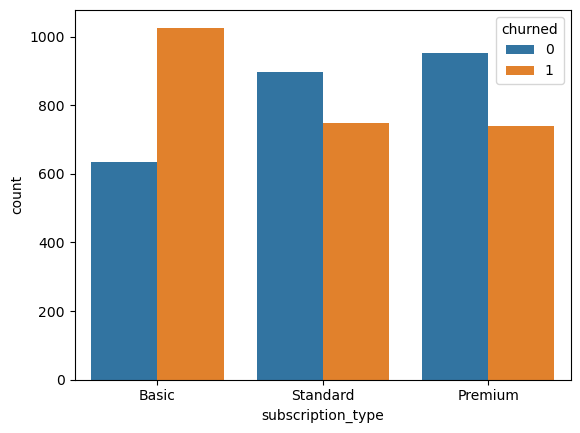

In [6]:
sns.countplot(x=df['subscription_type'],hue=df['churned'],data=df)

In [7]:
# basic plan users churn more

<Axes: xlabel='device', ylabel='count'>

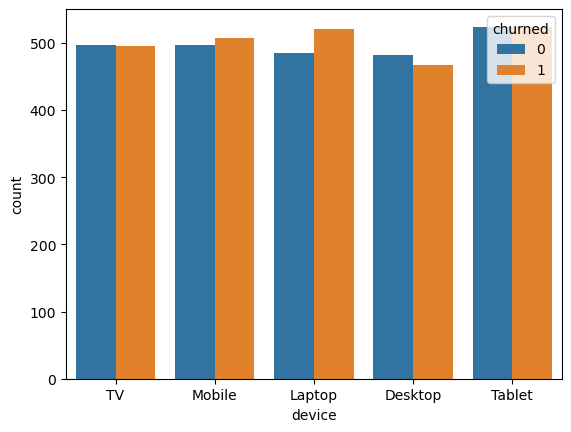

In [8]:
sns.countplot(x=df['device'],hue=df['churned'],data=df)

In [9]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='object')

In [11]:
df['churned'].value_counts(normalize=True)

churned
1    0.503
0    0.497
Name: proportion, dtype: float64